# **T1A** Thévenin Norton

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../..")
from base import *

In [15]:
R, VL, IL, VTh, ITh = getData('dados.txt')
VL, uVL, IL, uIL, VTh, uVTh, ITh, uITh=b.getData('dados_un.txt')

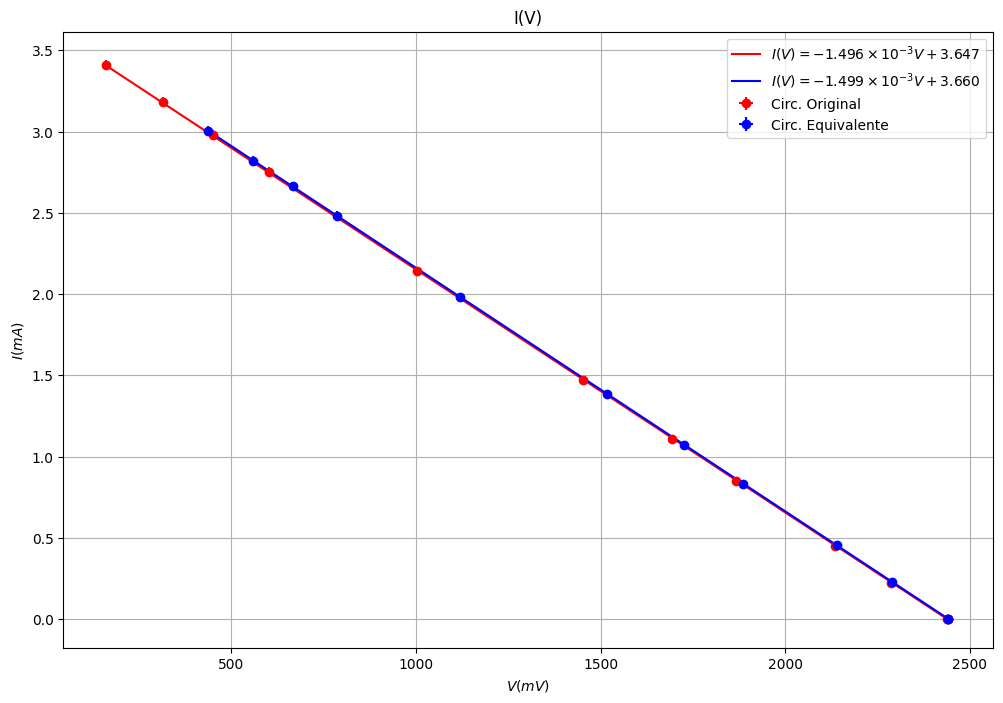

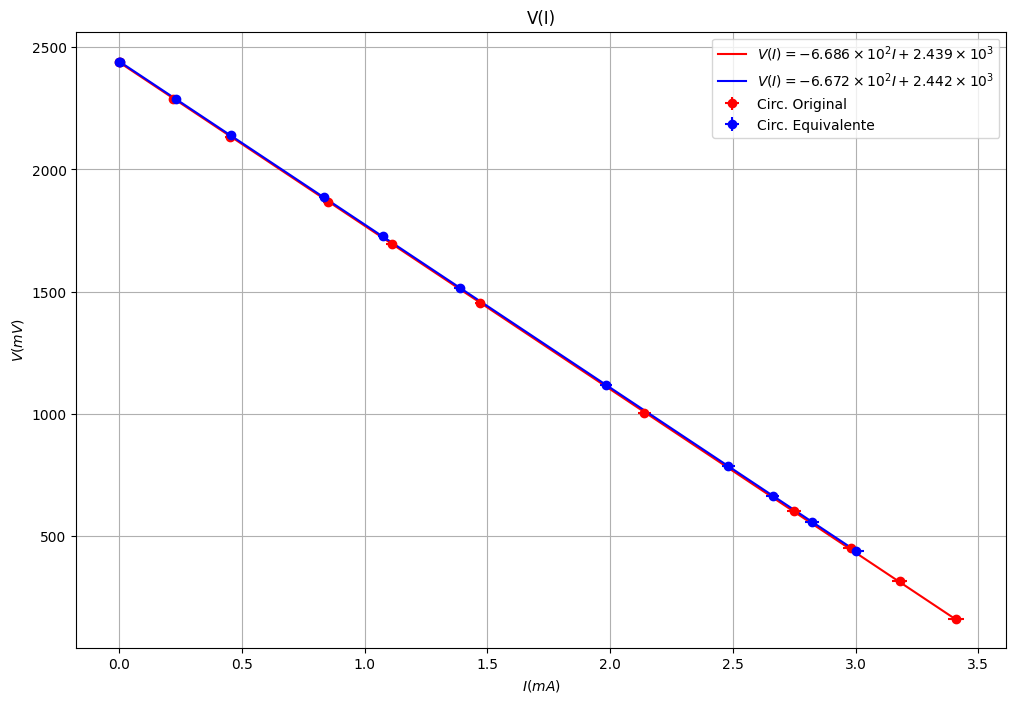

V=2.438551 ± 0.001217 V   ε=0.3%
I=-3.647205 ± 0.004248 mA
R=-668.608141 ± 1.216676 mΩ   ε=1.0%
V=2.438551 ± 0.001217 V   ε=0.3%
I=-3.647205 ± 0.004248 mA
R=-668.608141 ± 1.216676 mΩ   ε=1.0%


In [25]:
adjustsIV = plotMultipleReg([VL,VTh],[IL,ITh],[uVL,uVTh],[uIL,uITh],"I(V)","V (mV)","I (mA)",["red","blue"],["Circ. Original","Circ. Equivalente"])
adjustsVI = plotMultipleReg([IL,ITh],[VL,VTh],[uIL,uITh],[uVL,uVTh],"V(I)","I (mA)","V (mV)",["red","blue"],["Circ. Original","Circ. Equivalente"])

Vprev = 3.571
Rprev = 677.4

for i in range(0,2):

    print(f"V={adjustsVI[0].beta[1]/1000:3f} ± {adjustsVI[0].sd_beta[1]/1000:3f} V   ε={abs(adjustsVI[0].beta[1]/1000-Vprev)/Vprev:.1f}%")
    print(f"I={-adjustsIV[0].beta[1]:3f} ± {adjustsIV[0].sd_beta[1]:3f} mA")
    print(f"R={adjustsVI[0].beta[0]:3f} ± {adjustsVI[0].sd_beta[1]:3f} mΩ   ε={abs(adjustsVI[0].beta[0]/1000-Rprev)/Rprev:.1f}%")

In [17]:
print(1/adjustsIV[0].beta[0])

-668.608141437515


Beta: [-1.49564437e-03  3.64720526e+00]
Beta Std Error: [2.06964409e-06 4.24785730e-03]
Beta Covariance: [[ 6.10570156e-11 -1.17504321e-07]
 [-1.17504321e-07  2.57207766e-04]]
Residual Variance: 0.0701545367045864
Inverse Condition #: 0.00016929069845102762
Reason(s) for Halting:
  Sum of squares convergence
Beta: [-668.6081408  2438.55113012]
Beta Std Error: [0.92519484 1.21667627]
Beta Covariance: [[12.20142745 -9.38040798]
 [-9.38040798 21.10057631]]
Residual Variance: 0.07015453670529588
Inverse Condition #: 0.4855965335558718
Reason(s) for Halting:
  Sum of squares convergence


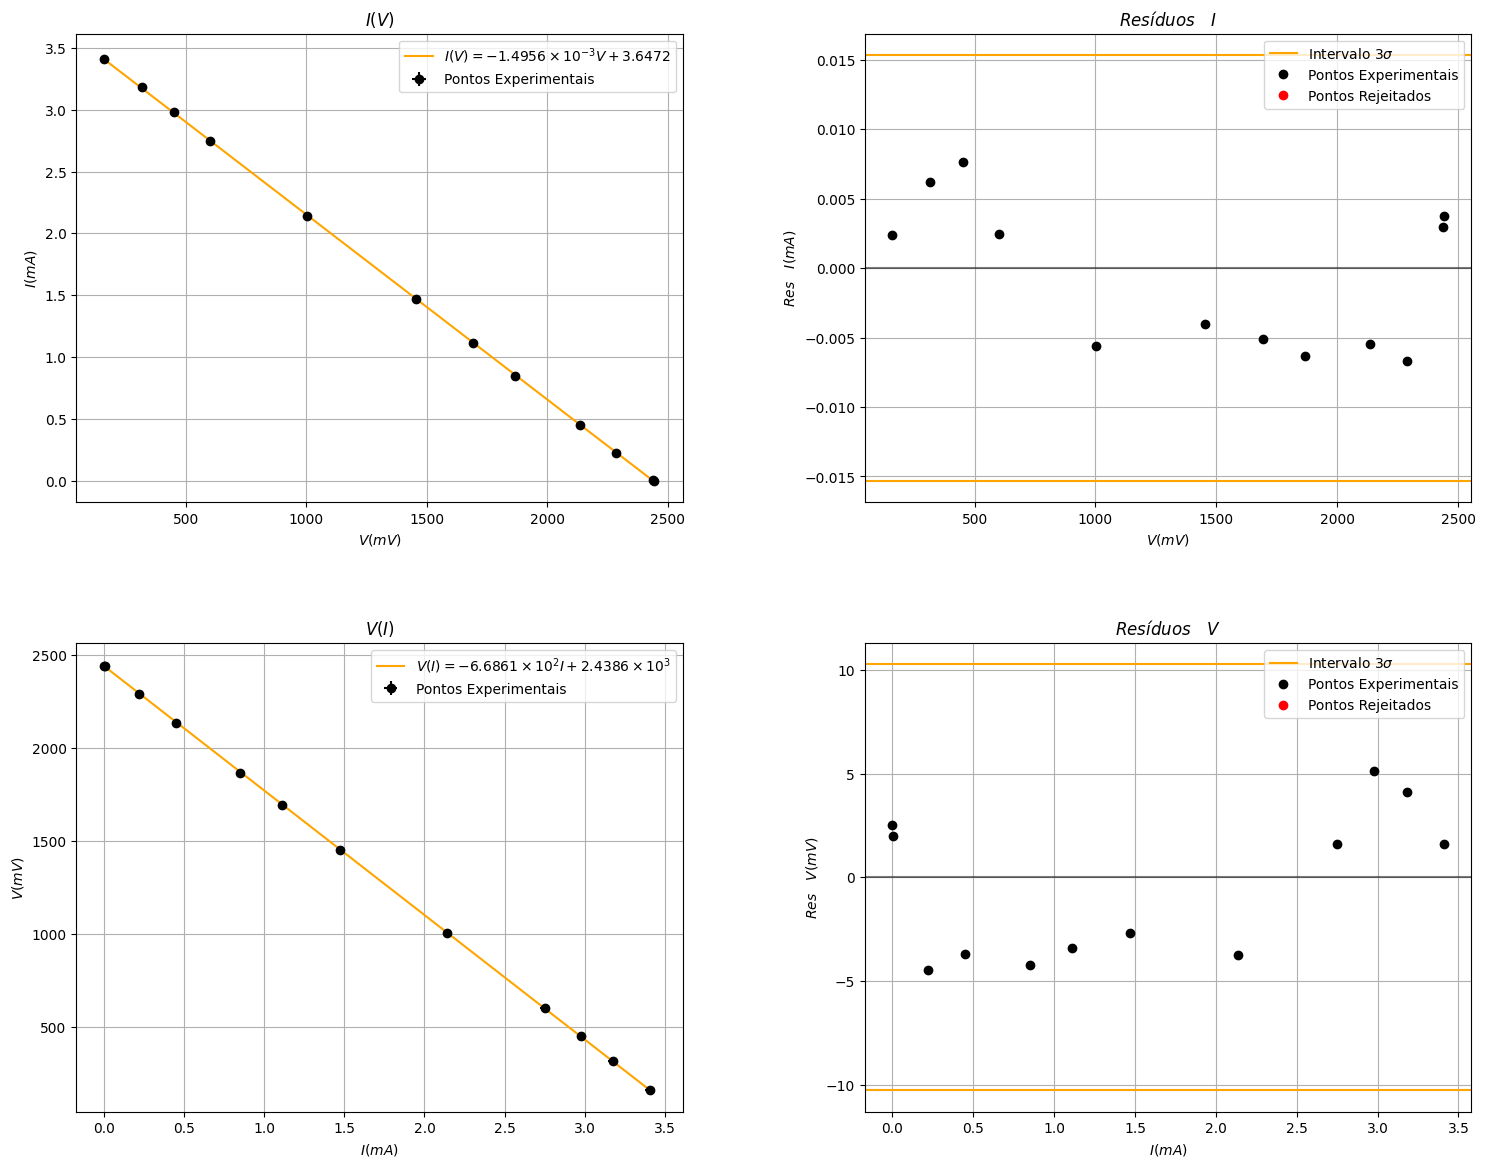

In [18]:
adjusts2 = plotColumnFullLinReg([VL,IL],[IL,VL],[uVL,uIL],[uIL,uVL],["I(V)","V(I)"],["V (mV)","I(mA)"],["I (mA)","V (mV)"], tol= 3,)
for i in adjusts2:
    i.pprint()

In [19]:
b.round_un(-668.6081408,0.092519484)
#b.round_un(-1.49564437e-03,2.06964409e-06)

array([-6.68608e+02,  9.30000e-02,  3.00000e+00])